# **propax : introductory tutorial**

`propax` gives you the thermodynamic properties of a fluid the way CoolProp does, except
everything is a JAX function: you can `jit` it, `vmap` it over a million states, and, the most important, **differentiate through it** ! This allows to plug it without loss of simplicity or performance in any JAX ML workflow.

**NOTE :** 

- `propax` also implements fast solvers that rely on interpolated tables, however they require 10mins of your time to be built, so in this tutorial nothing here needs the interpolation tables; this is also the opportunity to say that `flash` itself does not make any use of interpolation tables, which is not the case of `fast_flash` that at the surface behaves the same as its slow counterpart.

```
pip install -e ".[notebooks,coolprop]"
```

Thermodynamics might often be whimsical, solvers are likely to be running in high precision so that they can converge : `propax` solves it by making them compatible with 32bits and 64bits precisions ! It mainly does matter when you are interested in running `propax` on GPU (most of personal GPUs does not support high performance 64bits precision computations), this is no longer a problem !

In [1]:
import jax

jax.config.update("jax_enable_x64", False)  # PLEASE : run this notebook twice with True and False

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from propax import Interface

props = Interface.create("n-propane")

JAX is in 32-bit precision, so every solve stops at float32 round-off (~1e-7 relative) against ~1e-15 in float64, and `TOL32` is used rather than `TOL64`. Enable 64-bit unless you meant this:
import jax
jax.config.update('jax_enable_x64', True)


With this classmethod you can check which pairs are supported by `propax`, only two less than `CoolProp`, those are also supported by both the bracketed `flash` and its fast counterpart.

In [2]:
Interface.supported_pairs()

{('P', 'T'): 'one_dim',
 ('H', 'P'): 'nested',
 ('P', 'S'): 'nested',
 ('P', 'U'): 'nested',
 ('P', 'Q'): 'saturated',
 ('S', 'T'): 'one_dim',
 ('D', 'T'): 'natural',
 ('Q', 'T'): 'saturated',
 ('D', 'H'): 'one_dim',
 ('D', 'S'): 'one_dim',
 ('D', 'U'): 'one_dim'}

In [3]:
INK, LIQ, VAP = "#1b2733", "#2a6f97", "#c1502e"
ACCENT, MUTED = "#e07a3f", "#93a1ad"

## One call

`flash` takes any two properties and returns the whole state. It also returns a flag,
because a flash can fail and propax would rather say so than hand back a plausible number.

In [4]:
state, ok = props.flash("P", 5e5, "T", 300.0)

print(f"converged: {bool(ok)}")
for k, v in state.items():
    print(f"  {k} = {float(v):.4f}")

converged: True
  P = 499999.9375
  T = 300.0000
  cp = 1798.5485
  cv = 1525.4298
  h = 621298.8125
  rho = 9.6429
  s = 2525.5356
  u = 569447.3750


## Case 1 : the phase envelope

The saturation curve is a Chebyshev superancillary: solved offline from the EOS itself in
extended precision, not fitted to anyone's output. Reading it is one call, and it
vectorises, so the whole dome is a single `vmap`. We can use it to retrieve a entropy temperature diagram, see how isobars are flat under the dome, delimited by the saturation values.

In [5]:
sat = props.saturation
T_dome = jnp.linspace(sat.T_min, sat.T_crit, 500)
dome = jax.jit(jax.vmap(sat.state_T))(T_dome)
# I suggest you to print what the dome object is !

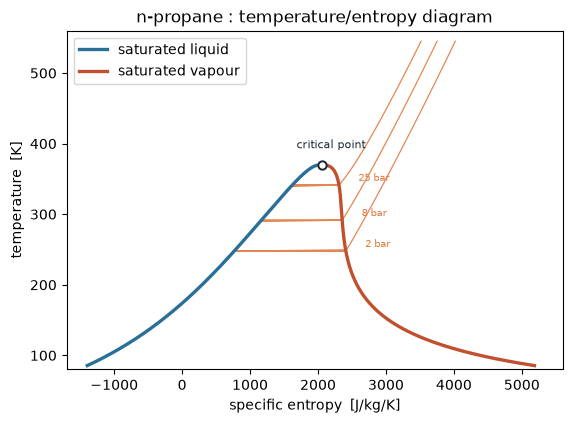

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))

s_L, s_V = dome.L["s"], dome.V["s"]

# jax.vmap vectorizes a function along specified axis, here we ask it to compute
# "s" at several "t" at "p" fixed (becomes a batched axis)
isobar = jax.jit(
    jax.vmap(lambda t, p: props.flash("T", t, "P", p)[0]["s"], in_axes=(0, None))
)
for P in (2e5, 8e5, 2.5e6):
    T_sat = float(sat.state_P(jnp.asarray(P)).T)
    lo = np.linspace(sat.T_min, T_sat, 120)
    hi = np.linspace(T_sat, 545.0, 160)
    i = int(np.argmin(np.abs(T_dome - T_sat)))
    ax.plot(
        np.r_[isobar(jnp.asarray(lo), P), s_L[i], s_V[i], isobar(jnp.asarray(hi), P)],
        np.r_[lo, T_sat, T_sat, hi],
        color=ACCENT,
        lw=0.9,
        alpha=0.9,
        zorder=2,
    )
    ax.annotate(
        f"{P / 1e5:g} bar",
        (s_V[i], T_sat),
        fontsize=7.5,
        color=ACCENT,
        xytext=(14, 3),
        textcoords="offset points",
        zorder=6,
    )

ax.plot(s_L, T_dome, color=LIQ, lw=2.4, label="saturated liquid", zorder=4)
ax.plot(s_V, T_dome, color=VAP, lw=2.4, label="saturated vapour", zorder=4)

ax.plot(s_L[-1], T_dome[-1], "o", ms=6, mfc="white", mec=INK, mew=1.4, zorder=6)
ax.annotate(
    "critical point",
    (s_L[-1], T_dome[-1]),
    xytext=(-18, 12),
    textcoords="offset points",
    fontsize=8,
    color=INK,
    zorder=6,
)

ax.set(
    xlabel="specific entropy  [J/kg/K]",
    ylabel="temperature  [K]",
    title="n-propane : temperature/entropy diagram",
    ylim=(80, 560),
    xlim=(-1700, 5600),
)
ax.legend(loc="upper left")
plt.show()

Also note that our superancillary perfectly converges exactly on the critical point, there is no need to substract a small epsilon or anything...

## Case 2 : vectorized call 

`vmap` turns the scalar flash into a grid evaluation. This is one of the most liked features about JAX, we use it in the following example to visualize isobaric heat capacity as a function of T and P, to do so we compute about 29 000 points in a fraction of seconds.

In [7]:
n = 170
T_grid = jnp.linspace(240.0, 640.0, n)  # up to the EOS's own T_max
P_grid = jnp.geomspace(5e4, 1e8, n)  # 0.5 bar to 1000 bar
TT, PP = jnp.meshgrid(T_grid, P_grid, indexing="ij")

cp_of = jax.jit(jax.vmap(lambda t, p: props.flash("T", t, "P", p)[0]["cp"]))
cp = np.asarray(cp_of(TT.ravel(), PP.ravel())).reshape(n, n)

# as before we use our superancillary to compute saturation pressure across the dome
P_sat_line = jax.jit(jax.vmap(lambda t: sat.state_T(t).P))(T_dome)

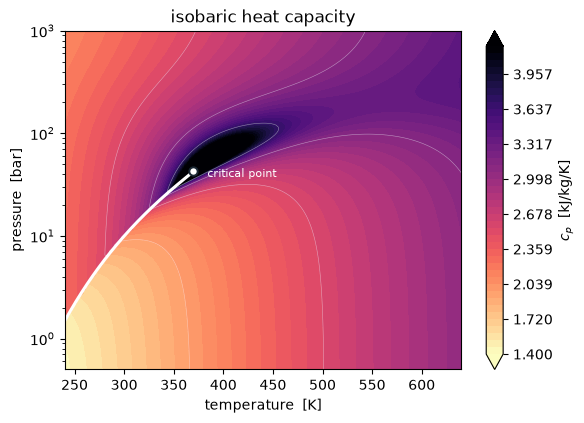

In [8]:
T_ax, P_ax = np.asarray(T_grid), np.asarray(P_grid) / 1e5
inside = (np.asarray(P_sat_line) / 1e5 >= P_ax[0]) & (T_dome >= T_ax[0])

fig, ax = plt.subplots(figsize=(6.4, 4.4))

levels = np.linspace(1.4, np.percentile(cp / 1000, 99.0), 45)
m = ax.contourf(T_ax, P_ax, cp.T / 1000, levels=levels, cmap="magma_r", extend="both")
ax.contour(
    T_ax,
    P_ax,
    cp.T / 1000,
    levels=levels[::9],
    colors="white",
    linewidths=0.4,
    alpha=0.5,
)
# the saturation line
ax.plot(T_dome[inside], (np.asarray(P_sat_line) / 1e5)[inside], color="white", lw=2.2)
ax.plot(
    T_dome[-1],
    float(P_sat_line[-1]) / 1e5,
    "o",
    ms=6,
    mfc="white",
    mec=INK,
    mew=1.4,
    zorder=5,
)
ax.annotate(
    "critical point",
    (T_dome[-1], float(P_sat_line[-1]) / 1e5),
    xytext=(10, -4),
    textcoords="offset points",
    fontsize=8,
    color="white",
)

ax.set(
    yscale="log",
    xlim=(T_ax[0], T_ax[-1]),
    ylim=(P_ax[0], P_ax[-1]),
    xlabel="temperature  [K]",
    ylabel="pressure  [bar]",
    title="isobaric heat capacity",
)
ax.grid(False)
fig.colorbar(m, ax=ax, label="$c_p$  [kJ/kg/K]")
plt.show()

The white line is the saturation curve, ending at the critical point; the bright ridge
climbing away from it into the supercritical region is the Widom line, where `c_p` peaks, this is naturally recomputed from the EOS.



## Case 3 : Derivatives and Autodiff

The Joule–Thomson coefficient is defined as a derivative: `mu = (dT/dP)` at fixed `h`. In propax it is extremely easy to compute thanks to JAX's mechanisms.

A few reminder first since `(dT/dP)` cannot be computed directly, the enthalpy can be expressed as $h = f(T, P)$ with $f$ some function, it stems that : 

$$dh = (\frac{\partial h}{\partial T})_P dT + (\frac{\partial h}{\partial P})_T dP$$

At $h$ fixed $dh = 0$ : 

$$(\frac{\partial h}{\partial T})_P dT = - (\frac{\partial h}{\partial P})_T dP$$

So : 

$$(\frac{\partial T}{\partial P})_h = - \frac{(\frac{\partial h}{\partial P})_T}{(\frac{\partial h}{\partial T})_P}$$

In `propax` this translates to : 

In [9]:
def h_of(T, P):
    return props.flash("T", T, "P", P)[0]["h"]


def mu_JT(T, P):
    return -jax.grad(h_of, argnums=1)(T, P) / jax.grad(h_of, argnums=0)(T, P)


print(f"mu_JT(400 K, 30 bar) = {mu_JT(400.0, 3e6) * 1e5:.6f} K/bar")

mu_JT(400 K, 30 bar) = 0.893921 K/bar


And now see how it composes with `jax.vmap` it over a grid.

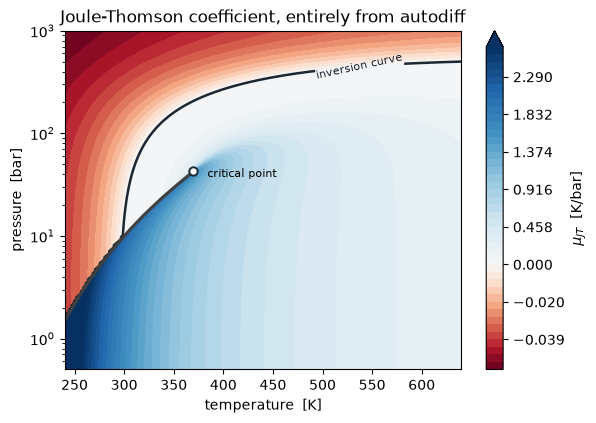

In [10]:
from matplotlib.colors import TwoSlopeNorm

mu = np.asarray(jax.jit(jax.vmap(mu_JT))(TT.ravel(), PP.ravel())).reshape(n, n) * 1e5

fig, ax = plt.subplots(figsize=(6.4, 4.4))

top = np.nanpercentile(mu, 99)  # avoid to take the max itself, can be an outlier
levels = np.r_[np.linspace(mu.min(), 0.0, 15)[:-1], np.linspace(0.0, top, 30)]
norm = TwoSlopeNorm(vmin=mu.min(), vcenter=0.0, vmax=top)

m = ax.contourf(T_ax, P_ax, mu.T, levels=levels, norm=norm, cmap="RdBu", extend="max")
inv = ax.contour(T_ax, P_ax, mu.T, levels=[0.0], colors=INK, linewidths=1.8)
# mu = 0 also runs along the phase boundary, so the label has to be pinned to the
# branch that is actually the inversion curve
ax.clabel(inv, fmt={0.0: "  inversion curve  "}, fontsize=8, manual=[(540.0, 400.0)])

ax.plot(T_dome[inside], (np.asarray(P_sat_line) / 1e5)[inside], color="0.25", lw=2.2)
ax.plot(  # the critical point
    T_dome[-1],
    float(P_sat_line[-1]) / 1e5,
    "o",
    ms=6,
    mfc="white",
    mec=INK,
    mew=1.4,
    zorder=5,
)
ax.annotate(
    "critical point",
    (T_dome[-1], float(P_sat_line[-1]) / 1e5),
    xytext=(10, -4),
    textcoords="offset points",
    fontsize=8,
    color="black",
)

ax.set(
    yscale="log",
    xlim=(T_ax[0], T_ax[-1]),
    ylim=(P_ax[0], P_ax[-1]),
    xlabel="temperature  [K]",
    ylabel="pressure  [bar]",
    title="Joule-Thomson coefficient, entirely from autodiff",
)
ax.grid(False)
fig.colorbar(m, ax=ax, label=r"$\mu_{JT}$  [K/bar]")
plt.show()

Blue is cooling on expansion, red is heating. It is worth checking against CoolProp, which computes the same coefficient analytically (in CoolProp derivatives are entirely written explicitely) :

In [11]:
import CoolProp.CoolProp as CP

print("T (K)\tP (bar)\tpropax\t\tCoolProp\trel")
for T, P in [(300.0, 5e5), (400.0, 3e6), (500.0, 8e6)]:
    ours = float(mu_JT(T, P))
    theirs = CP.PropsSI("d(T)/d(P)|H", "T", T, "P", P, "n-Propane")
    print(
        f"{T:.0f}\t{P / 1e5:.0f}\t{ours:.6e}\t{theirs:.6e}\t{abs(ours - theirs) / abs(theirs):.1e}"
    )

T (K)	P (bar)	propax		CoolProp	rel
300	5	1.831892e-05	1.831893e-05	5.6e-07
400	30	8.939205e-06	8.939208e-06	3.2e-07
500	80	3.893663e-06	3.893660e-06	7.6e-07


## Checking accuracy and speed

propax and CoolProp evaluate the same published correlation, so on a well-posed flash they
should agree to round-off; and they do. Let's visualize the tail of errors.

Below we run a round trip test : do the same with CoolProp, it is instructive to see that it solves its own equations with less accuracy than propax. If you own a GPU, switch to 32bits precision mode (top of notebook) and see that solving for 10_000 PH flashes with `propax` takes no more than twelve seconds (compilation included) while it goes to 6mins with CoolProp !

```python
P = jnp.linspace(some_lower_bound, some_lower_bound, num=int(3e3))
H = jnp.linspace(some_lower_bound, some_lower_bound, num=int(3e3))

PP, HH = jnp.meshgrid(T, D, indexing="xy")
PP_flat, HH_flat = TT.ravel(), DD.ravel()

points_to_solve = jax.block_until_ready(jax.jit(jax.vmap(lambda p, h : props.flash("P", p, "H", h))))(PP_flat, HH_flat)
```

In [12]:
from propax.core.config import PhaseID

T = jnp.linspace(props.eos.T_triple, props.eos.T_max, num=int(1e3))
D = jnp.linspace(props.eos.rho_crit_mass, props.saturation.rho_max, num=int(1e3))

TT, DD = jnp.meshgrid(T, D, indexing="xy")
TT_flat, DD_flat = TT.ravel(), DD.ravel()

points_to_solve = jax.jit(jax.vmap(props.props_rhoT))(DD_flat, TT_flat)
is_in_dome = jax.jit(jax.vmap(lambda t, d: props.check_phase("T", t, "D", d)))(
    TT_flat, DD_flat
) == PhaseID.TWO_PHASE


/home/emmanuel/Documents/GitHub/propax/src/propax/core/flash/results.py:71: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  pad_val = jnp.asarray(0.0, dtype=dtype)


In [13]:
flash_batch = jax.jit(jax.vmap(lambda p, h: props.flash("P", p, "H", h)))
props_out, ok = flash_batch(points_to_solve["P"], points_to_solve["h"])

res = jnp.abs(TT_flat - props_out["T"]) / TT_flat
keep = ~is_in_dome & ok


In [14]:
res # should be around 1e-5 in float32 and less in float64 

Array(shape=(1000000,), dtype=float32)

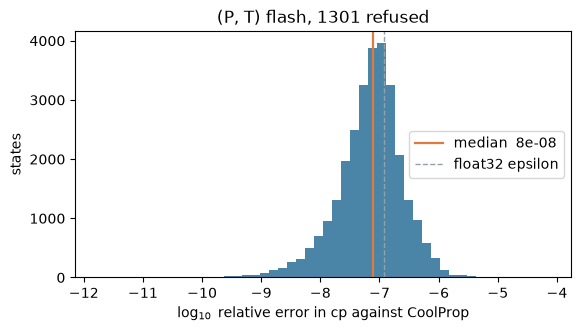

In [16]:
n = 170
T_grid = jnp.linspace(240.0, 640.0, n)  # up to the EOS's own T_max
P_grid = jnp.geomspace(5e4, 1e8, n)  # 0.5 bar to 1000 bar
TT, PP = jnp.meshgrid(T_grid, P_grid, indexing="ij")

jit_px = jax.jit(jax.vmap(lambda t, p: props.flash("T", t, "P", p)))
results_px, flags = jit_px(TT.ravel(), PP.ravel())
cp_px = np.asarray(results_px["cp"])
cp_coolprop = CP.PropsSI("CPMASS", "T", TT.ravel(), "P", PP.ravel(), "n-Propane")

err = np.abs(np.asarray(cp_px) - cp_coolprop) / cp_coolprop

exact = int((err == 0).sum())

if jax.config.read("jax_enable_x64"):  # type: ignore
    eps = np.log10(float(jnp.finfo(jnp.float64).eps))
    prec = "float64"
else: 
    eps = np.log10(float(jnp.finfo(jnp.float32).eps))
    prec = "float32"

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(np.log10(err[err > 0]), bins=50, color=LIQ, alpha=0.85, lw=0)
ax.axvline(
    np.log10(np.median(err[err > 0])),
    color=ACCENT,
    lw=1.6,
    label=f"median  {np.median(err[err > 0]):.0e}",
)
ax.axvline(eps, color=MUTED, lw=1, ls="--", label=f"{prec} epsilon")

ax.set(
    xlabel=r"$\log_{10}$ relative error in cp against CoolProp",
    ylabel="states",
    title=f"(P, T) flash, {int((~np.asarray(flags)).sum())} refused",
)
ax.legend(loc="center right")
plt.show()

## Speed

`vmap` is SIMT rather than C++ vectorisation: a batch runs as one lane-locked loop, so the
slowest state in it sets the pace for all of them. That is why propax has to converge
everywhere in the domain within a *fixed* iteration count, and it is the constraint that
shapes the solvers.

The practical consequence is that the gain is real in batch and negative for a single
state. Both are worth seeing.

In [21]:
from time import perf_counter


def best_of(fn, *args, repeat=3):
    jax.block_until_ready(fn(*args))
    times = []
    for _ in range(repeat):
        t0 = perf_counter()
        jax.block_until_ready(fn(*args))
        times.append(perf_counter() - t0)
    return min(times)


# 200 000 inputs
unique_P, unique_H = 5e5, 3.6e5 # valid inputs for n-Propane
NB = 200_000
P_np, H_np = np.resize(unique_P, NB), np.resize(unique_H, NB)
Pb, Hb = jnp.asarray(P_np), jnp.asarray(H_np)

# Benchmark Batch
# propax (JAX vmap)
batch = jax.jit(jax.vmap(lambda p_, h_: props.flash("P", p_, "H", h_)))
t_px = best_of(batch, Pb, Hb)

# CoolProp (C++ vectorized)
_ = CP.PropsSI("T", "P", P_np[:10], "H", H_np[:10], "n-Propane")  # Warmup
t0 = perf_counter()
_ = CP.PropsSI("T", "P", P_np, "H", H_np, "n-Propane")
t_cp = perf_counter() - t0

# Unique call benchmark
p1, h1 = float(P_np[0]), float(H_np[0])

# propax
one = jax.jit(lambda p_, h_: props.flash("P", p_, "H", h_))
t_one = best_of(one, jnp.asarray(p1), jnp.asarray(h1), repeat=20)

# CoolProp
t0 = perf_counter()
for _ in range(20):
    CP.PropsSI("T", "P", p1, "H", h1, "n-Propane")
t_cp1 = (perf_counter() - t0) / 20


fps_cp = NB / t_cp
fps_px = NB / t_px
lat_cp = t_cp1 * 1e6
lat_px = t_one * 1e6

batch_results = [
    ("CoolProp (PropsSI vectorisé)", f"{fps_cp:,.0f} pts/s"),
    ("propax (vmap JAX)", f"{fps_px:,.0f} pts/s"),
    ("--> Speedup propax", f"{fps_px / fps_cp:.1f}x"),
]

single_results = [
    ("CoolProp (PropsSI)", f"{lat_cp:.1f} µs"),
    ("propax (flash)", f"{lat_px:.1f} µs"),
]


def print_block(title, items):
    print(f"\n{title}\n")
    w = max(len(label) for label, _ in items)
    for label, val in items:
        print(f"  {label.ljust(w)} : {val}")


print("=" * 45)
print(" Benchmark : (P, H) -> T")
print("=" * 45)

print_block(f"Batch ({NB:,} states) :", batch_results)
print("-" * 45)
print_block("Unique call :", single_results)

print("=" * 45)

 Benchmark : (P, H) -> T

Batch (200,000 states) :

  CoolProp (PropsSI vectorisé) : 456,216 pts/s
  propax (vmap JAX)            : 10,603,334 pts/s
  --> Speedup propax           : 23.2x
---------------------------------------------

Unique call :

  CoolProp (PropsSI) : 172.4 µs
  propax (flash)     : 2111.7 µs


If you want to try fast flashes using bicubic interpolations, `props.fast_flash`, build its tables first, naming the pairs you use and the bounds of each of their variables :

`python -m propax.build_tables n-propane --pair P H --bounds P=1e4:5e6 H=-3e5:1.5e6` (add `--target 1e-6` if you're picky ;)).

`state, reliable = props.fast_flash("P", 5e5, "H", 3.6e5)` : `reliable` is False where the answer is extrapolated, or off the table's bounds.

## Want to know more ? 

- `docs/eos.md` 
- `docs/flash.md`
- `docs/superancillary.md` 
- `python -m propax.make_fluid <Name>` 